<a href="https://colab.research.google.com/github/alexa21342/CSCI-167/blob/CSCI-167-Assignments/3_1_Shallow_Networks_I.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Notebook 3.1 -- Shallow neural networks I**

The purpose of this notebook is to gain some familiarity with shallow neural networks with 1D inputs.  It works through an example similar to figure 3.3 and experiments with different activation functions. <br>

Work through the cells below, running each cell in turn. In various places you will see the words "TODO". Follow the instructions at these places and write code to complete the functions. There are also questions interspersed in the text.

Contact me at udlbookmail@gmail.com if you find any mistakes or have any suggestions.

In [ ]:
# Imports math library
import numpy as np
# Imports plotting library
import matplotlib.pyplot as plt

Let's first construct the shallow neural network with one input, three hidden units, and one output described in section 3.1 of the book.

In [ ]:
# Define the Rectified Linear Unit (ReLU) function
def ReLU(preactivation):
  # TODO write code to implement the ReLU and compute the activation at the
  # hidden unit from the preactivation
  # This should work on every element of the ndarray "preactivation" at once
  # One way to do this is with the ndarray "clip" function
  # https://numpy.org/doc/stable/reference/generated/numpy.ndarray.clip.html

  # previous code ->activation = np.zeros_like(preactivation);

  activation = preactivation.clip(min=0)


  return activation

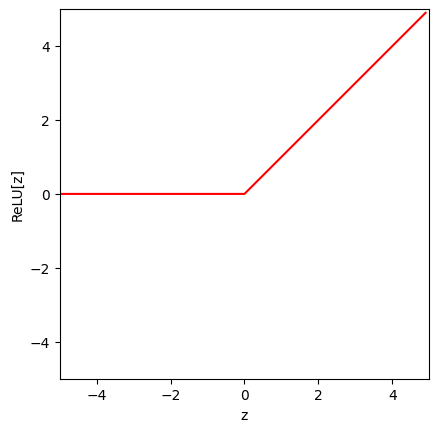

In [ ]:
# Make an array of inputs
z = np.arange(-5,5,0.1)
RelU_z = ReLU(z)

# Plot the ReLU function
fig, ax = plt.subplots()
ax.plot(z,RelU_z,'r-')
ax.set_xlim([-5,5]);ax.set_ylim([-5,5])
ax.set_xlabel('z'); ax.set_ylabel('ReLU[z]')
ax.set_aspect('equal')
plt.show()

In [ ]:
# Define a shallow neural network with, one input, one output, and three hidden units
def shallow_1_1_3(x, activation_fn, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31):
  # TODO Replace the code below to compute the three initial lines
  # from the theta parameters (i.e. implement equations at bottom of figure 3.3a-c).  These are the preactivations
#  pre_1 = np.zeros_like(x)
#  pre_2 = np.zeros_like(x)
#  pre_3 = np.zeros_like(x)
  pre_1 = theta_10 + theta_11 * x
  pre_2 = theta_20 + theta_21 * x
  pre_3 = theta_30 + theta_31 * x

  # Pass these through the ReLU function to compute the activations as in
  # figure 3.3 d-f
  act_1 = activation_fn(pre_1)
  act_2 = activation_fn(pre_2)
  act_3 = activation_fn(pre_3)

  # TODO Replace the code below to weight the activations using phi1, phi2 and phi3
  # To create the equivalent of figure 3.3 g-i
#  w_act_1 = np.zeros_like(x)
#  w_act_2 = np.zeros_like(x)
#  w_act_3 = np.zeros_like(x)
  w_act_1 = phi_1 * act_1
  w_act_2 = phi_2 * act_2
  w_act_3 = phi_3 * act_3

  # TODO Replace the code below to combining the weighted activations and add
  # phi_0 to create the output as in figure 3.3 j
 # y = np.zeros_like(x)
  y = phi_0 + w_act_1 + w_act_2 + w_act_3

  # Return everything we have calculated
  return y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3

In [ ]:
# Plot the shallow neural network.  We'll assume input in is range [0,1] and output [-1,1]
# If the plot_all flag is set to true, then we'll plot all the intermediate stages as in Figure 3.3
def plot_neural(x, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=False, x_data=None, y_data=None):

  # Plot intermediate plots if flag set
  if plot_all:
    fig, ax = plt.subplots(3,3)
    fig.set_size_inches(8.5, 8.5)
    fig.tight_layout(pad=3.0)
    ax[0,0].plot(x,pre_1,'r-'); ax[0,0].set_ylabel('Preactivation')
    ax[0,1].plot(x,pre_2,'b-'); ax[0,1].set_ylabel('Preactivation')
    ax[0,2].plot(x,pre_3,'g-'); ax[0,2].set_ylabel('Preactivation')
    ax[1,0].plot(x,act_1,'r-'); ax[1,0].set_ylabel('Activation')
    ax[1,1].plot(x,act_2,'b-'); ax[1,1].set_ylabel('Activation')
    ax[1,2].plot(x,act_3,'g-'); ax[1,2].set_ylabel('Activation')
    ax[2,0].plot(x,w_act_1,'r-'); ax[2,0].set_ylabel('Weighted Act')
    ax[2,1].plot(x,w_act_2,'b-'); ax[2,1].set_ylabel('Weighted Act')
    ax[2,2].plot(x,w_act_3,'g-'); ax[2,2].set_ylabel('Weighted Act')

    for plot_y in range(3):
      for plot_x in range(3):
        ax[plot_y,plot_x].set_xlim([0,1]);ax[plot_x,plot_y].set_ylim([-1,1])
        ax[plot_y,plot_x].set_aspect(0.5)
      ax[2,plot_y].set_xlabel('Input, $x$');
    plt.show()

  fig, ax = plt.subplots()
  ax.plot(x,y)
  ax.set_xlabel('Input, $x$'); ax.set_ylabel('Output, $y$')
  ax.set_xlim([0,1]);ax.set_ylim([-1,1])
  ax.set_aspect(0.5)
  if x_data is not None:
    ax.plot(x_data, y_data, 'mo')
    for i in range(len(x_data)):
      ax.plot(x_data[i], y_data[i],)
  plt.show()

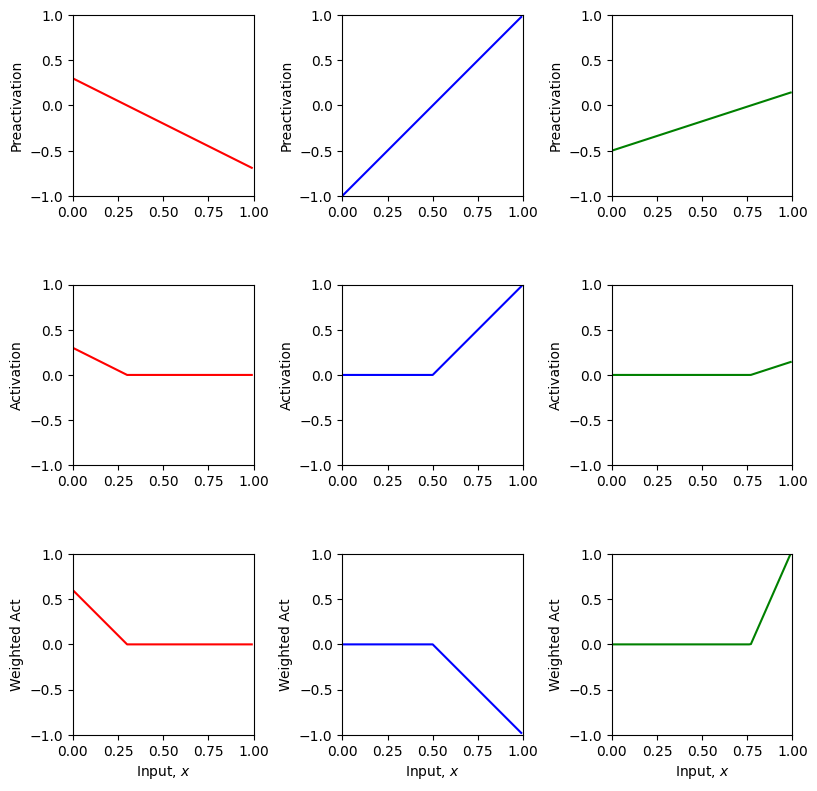

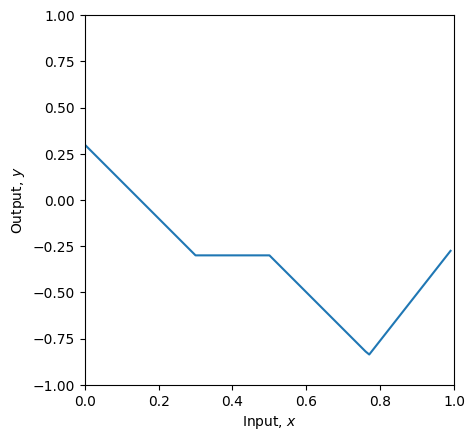

In [ ]:
# Now lets define some parameters and run the neural network
theta_10 =  0.3 ; theta_11 = -1.0
theta_20 = -1.0  ; theta_21 = 2.0
theta_30 = -0.5  ; theta_31 = 0.65
phi_0 = -0.3; phi_1 = 2.0; phi_2 = -1.0; phi_3 = 7.0

# Define a range of input values
x = np.arange(0,1,0.01)

# We run the neural network for each of these input values
y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3 = \
    shallow_1_1_3(x, ReLU, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31)
# And then plot it
plot_neural(x, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=True)

If your code is correct, then the final output should look like this:


Now let's play with the parameters to make sure we understand how they work.  The original  parameters were:

$\theta_{10} =  0.3$ ; $\theta_{11} = -1.0$<br>
$\theta_{20} =  -1.0$ ; $\theta_{21} = 2.0$<br>
$\theta_{30} =  -0.5$ ; $\theta_{31} = 0.65$<br>
$\phi_0 = -0.3; \phi_1 = 2.0; \phi_2 = -1.0; \phi_3 = 7.0$

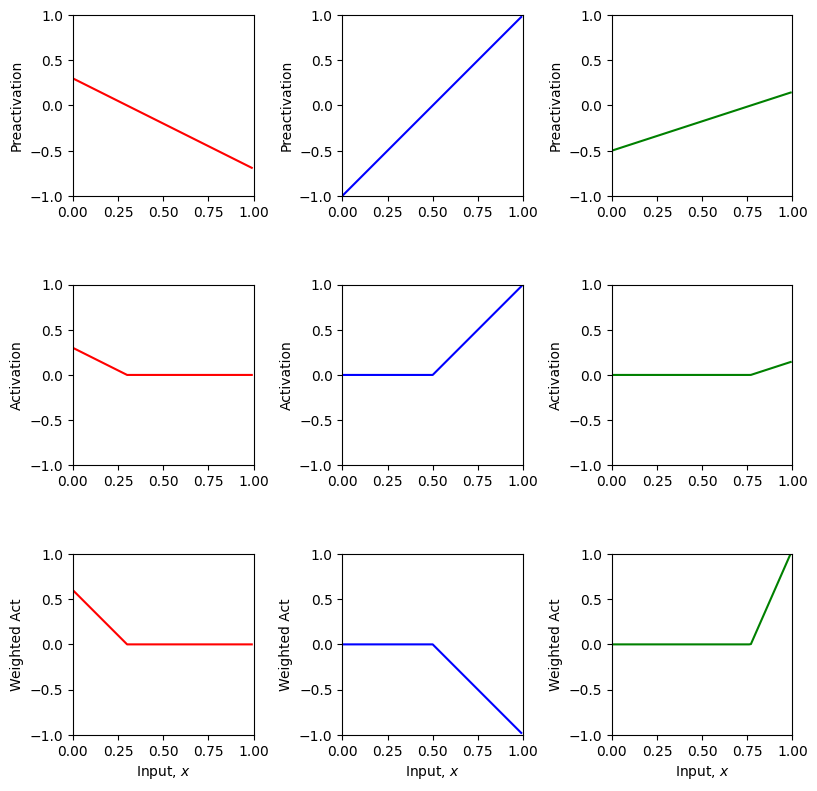

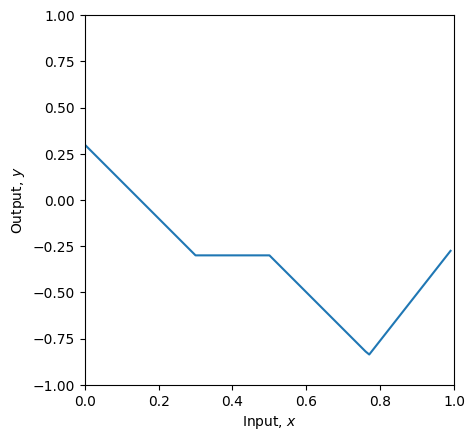

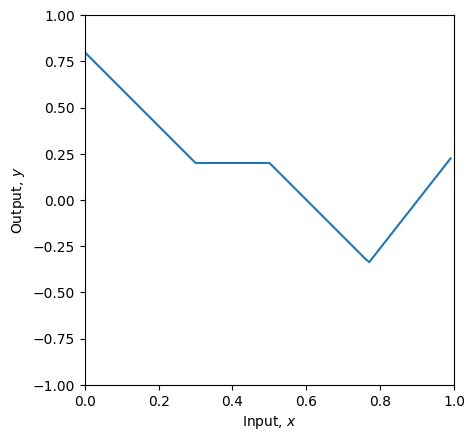

Q1: Changed phi_0 by +0.5 → vertical shift (joints unchanged)


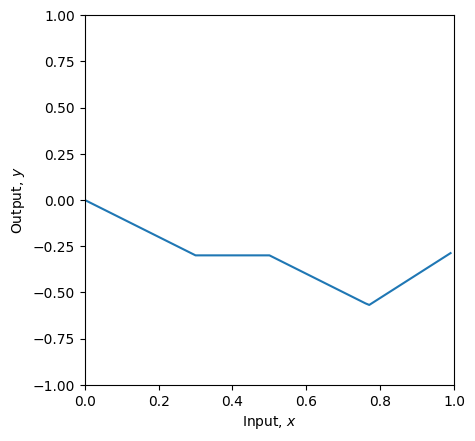

Q2: Halved (phi_1,phi_2,phi_3) → same shape, scaled down


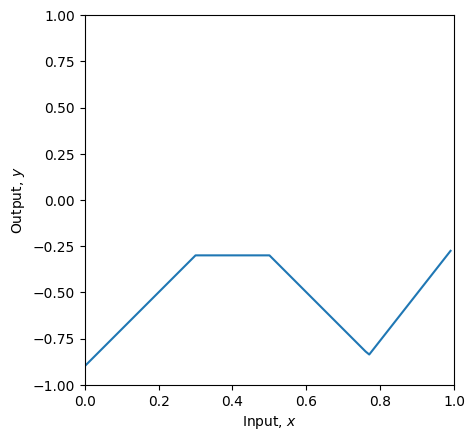

Q3: Flipped phi_1 sign → slope flipped where unit 1 is active


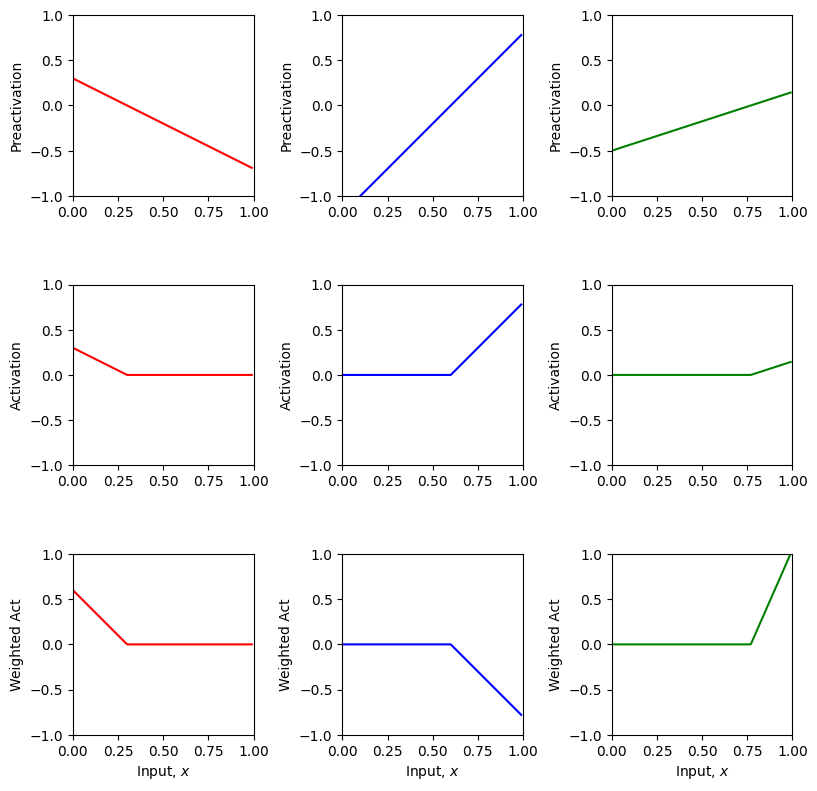

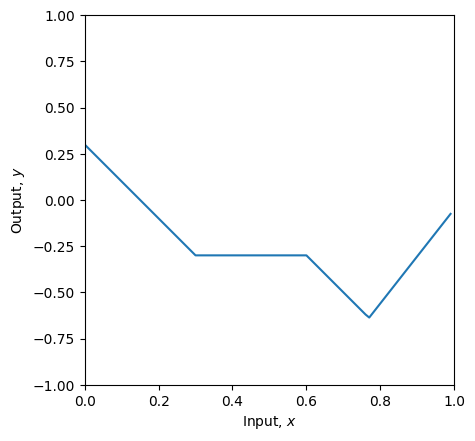

Q4: Set theta_20=-1.2 → unit-2 hinge shifts right to ~0.6


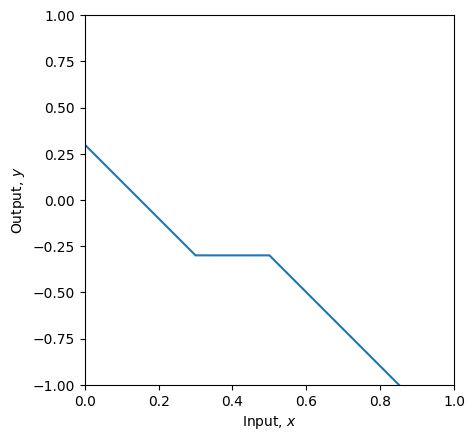

Q5A: Hinge outside range → only two joints


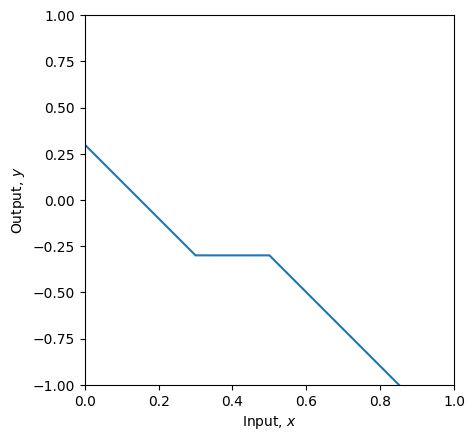

Q5B: Set phi_3=0 → only two joints


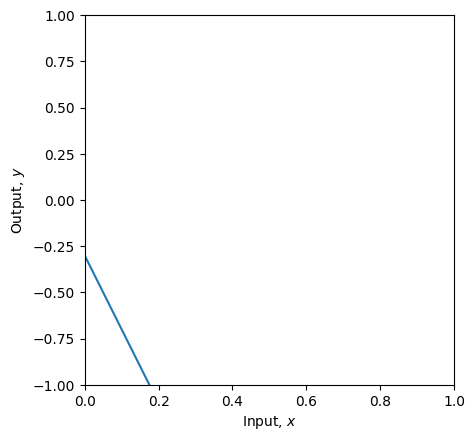

Q5C: Coincident hinges → only two joints


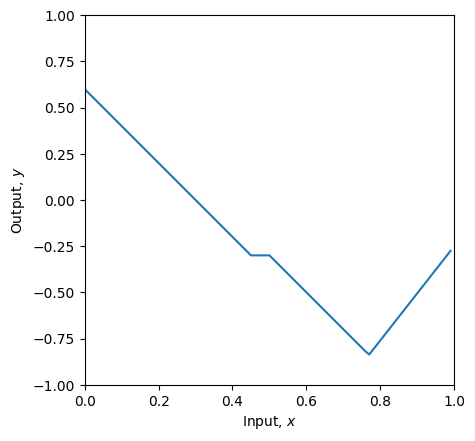

Q6: Adjusted theta_10 → middle segment gains slope


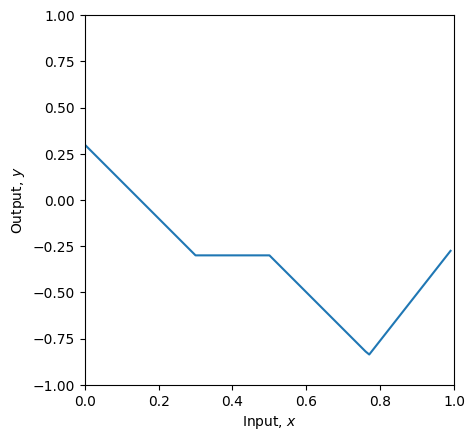

Q7: Scaled theta's and phi_2 → output nearly unchanged


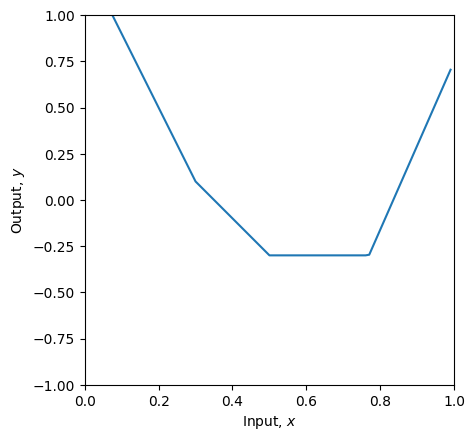

Q8: Negative scaling → unit-2 active side flips; output changes near hinge


In [ ]:
# TODO
# 1. Predict what effect changing phi_0 will have on the network.

# 2. Predict what effect multiplying phi_1, phi_2, phi_3 by 0.5 would have.  Check if you are correct

# 3. Predict what effect multiplying phi_1 by -1 will have.  Check if you are correct.

# 4. Predict what effect setting theta_20 to -1.2 will have.  Check if you are correct.

# 5. Change the parameters so that there are only two "joints" (including outside the range of the plot)
# There are actually three ways to do this. See if you can figure them all out

# 6. With the original parameters, the second line segment is flat (i.e. has slope zero)
# How could you change theta_10 so that all of the segments have non-zero slopes

# 7. What do you predict would happen if you multiply theta_20 and theta21 by 0.5, and phi_2 by 2.0?
# Check if you are correct.

# 8. What do you predict would happen if you multiply theta_20 and theta21 by -0.5, and phi_2 by -2.0?
# Check if you are correct.

theta_10 =  0.3 ; theta_11 = -1.0
theta_20 = -1.0  ; theta_21 = 2.0
theta_30 = -0.5  ; theta_31 = 0.65
phi_0 = -0.3; phi_1 = 2.0; phi_2 = -1.0; phi_3 = 7.0

# Define a range of input values
x = np.arange(0,1,0.01)

# We run the neural network for each of these input values
y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3 = \
    shallow_1_1_3(x, ReLU, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31)
# And then plot it
plot_neural(x, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=True)


# 1. Change phi_0 → vertical shift
phi0_test = phi_0 + 0.5
y1, *_ = shallow_1_1_3(x, ReLU, phi0_test, phi_1, phi_2, phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31)
plot_neural(x, y1, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=False)
print("Q1: Changed phi_0 by +0.5 → vertical shift (joints unchanged)")


# 2. Halve phi_1, phi_2, phi_3 → same shape, half amplitude
phi1_test, phi2_test, phi3_test = phi_1*0.5, phi_2*0.5, phi_3*0.5
y2, *_ = shallow_1_1_3(x, ReLU, phi_0, phi1_test, phi2_test, phi3_test, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31)
plot_neural(x, y2, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=False)
print("Q2: Halved (phi_1,phi_2,phi_3) → same shape, scaled down")


# 3. Flip phi_1 sign → slope changes where hidden unit 1 is active
phi1_test = -phi_1
y3, *_ = shallow_1_1_3(x, ReLU, phi_0, phi1_test, phi_2, phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31)
plot_neural(x, y3, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=False)
print("Q3: Flipped phi_1 sign → slope flipped where unit 1 is active")


# 4. Change theta_20 to -1.2 → hinge moves from 0.5 to 0.6
theta20_test = -1.2
y4, pre1_4, pre2_4, pre3_4, act1_4, act2_4, act3_4, w1_4, w2_4, w3_4 = \
    shallow_1_1_3(x, ReLU, phi_0, phi_1, phi_2, phi_3, theta_10, theta_11, theta20_test, theta_21, theta_30, theta_31)
plot_neural(x, y4, pre1_4, pre2_4, pre3_4, act1_4, act2_4, act3_4, w1_4, w2_4, w3_4, plot_all=True)
print("Q4: Set theta_20=-1.2 → unit-2 hinge shifts right to ~0.6")


# 5. Only two joints
# A: push unit 3 hinge outside range
theta30_A, theta31_A = -10.0, theta_31
y5A, *_ = shallow_1_1_3(x, ReLU, phi_0, phi_1, phi_2, phi_3, theta_10, theta_11, theta_20, theta_21, theta30_A, theta31_A)
plot_neural(x, y5A, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=False)
print("Q5A: Hinge outside range → only two joints")

# B: zero unit-3 output weight
phi3_B = 0.0
y5B, *_ = shallow_1_1_3(x, ReLU, phi_0, phi_1, phi_2, phi3_B, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31)
plot_neural(x, y5B, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=False)
print("Q5B: Set phi_3=0 → only two joints")

# C: make two hinges coincide
theta20_C = -(theta_10/theta_11) * theta_21
y5C, *_ = shallow_1_1_3(x, ReLU, phi_0, phi_1, phi_2, phi_3, theta_10, theta_11, theta20_C, theta_21, theta_30, theta_31)
plot_neural(x, y5C, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=False)
print("Q5C: Coincident hinges → only two joints")


# 6. Change theta_10 so all segments have non-zero slopes
theta10_test = theta_10 + 0.15
y6, *_ = shallow_1_1_3(x, ReLU, phi_0, phi_1, phi_2, phi_3, theta10_test, theta_11, theta_20, theta_21, theta_30, theta_31)
plot_neural(x, y6, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=False)
print("Q6: Adjusted theta_10 → middle segment gains slope")


# 7. Multiply theta_20, theta_21 by 0.5; phi_2 by 2.0 → output ~ unchanged
theta20_7, theta21_7 = theta_20*0.5, theta_21*0.5
phi2_7 = phi_2*2.0
y7, *_ = shallow_1_1_3(x, ReLU, phi_0, phi_1, phi2_7, phi_3, theta_10, theta_11, theta20_7, theta21_7, theta_30, theta_31)
plot_neural(x, y7, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=False)
print("Q7: Scaled theta's and phi_2 → output nearly unchanged")


# 8. Multiply theta_20, theta_21 by -0.5; phi_2 by -2.0 → active side flips
theta20_8, theta21_8 = theta_20*(-0.5), theta_21*(-0.5)
phi2_8 = phi_2*(-2.0)
y8, *_ = shallow_1_1_3(x, ReLU, phi_0, phi_1, phi2_8, phi_3, theta_10, theta_11, theta20_8, theta21_8, theta_30, theta_31)
plot_neural(x, y8, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=False)
print("Q8: Negative scaling → unit-2 active side flips; output changes near hinge")


# Least squares loss

Now let's consider fitting the network to data.  First we need to define the loss function.  We'll use the least squares loss:

\begin{equation}
L[\boldsymbol\phi] = \sum_{i=1}^{I}(y_{i}-\text{f}[x_{i},\boldsymbol\phi])^2
\end{equation}

where $(x_i,y_i)$ is an input/output training pair and $\text{f}[\bullet,\boldsymbol\phi]$ is the neural network with parameters $\boldsymbol\phi$.  The first term in the brackets is the ground truth output and the second term is the prediction of the model

In [ ]:
# Least squares function
def least_squares_loss(y_train, y_predict):
  # TODO Replace the line below to compute the sum of squared
  # differences between the real values of y and the predicted values from the model f[x_i,phi]
  # (see figure 2.2 of the book)
  # you will need to use the function np.sum
#   loss = 0

  loss = np.sum((y_train - y_predict) ** 2)

  return loss


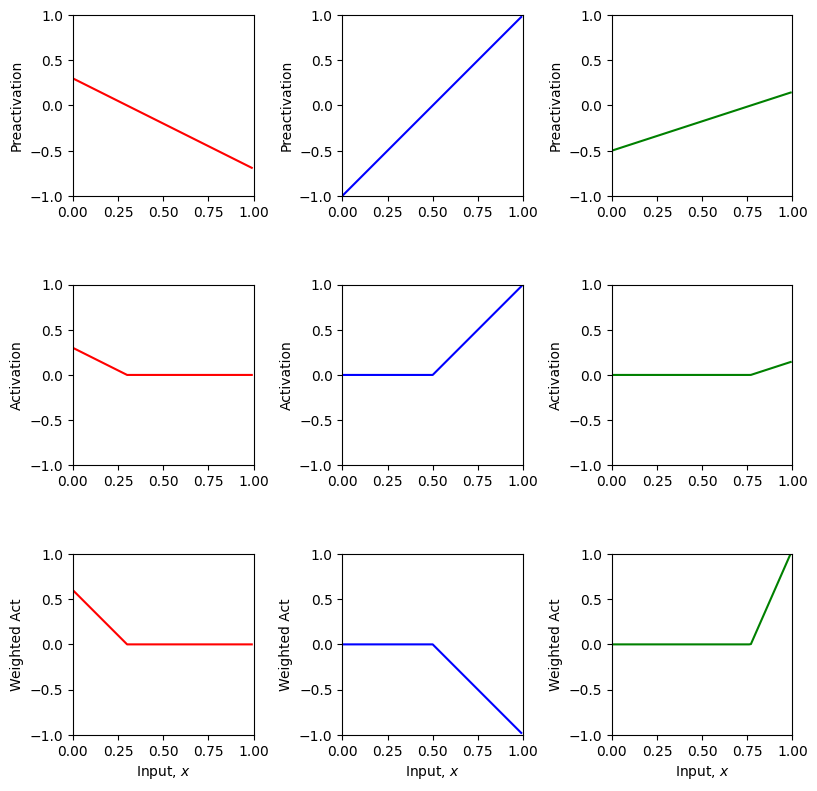

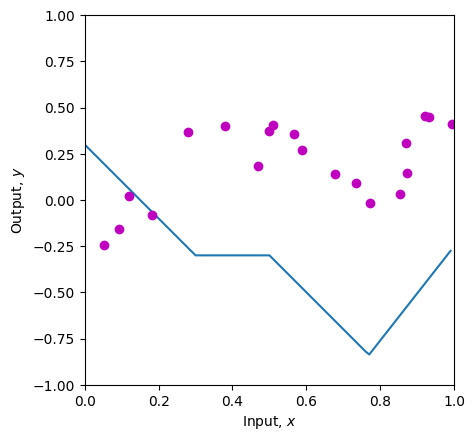

Your Loss = 9.385, True value = 9.385


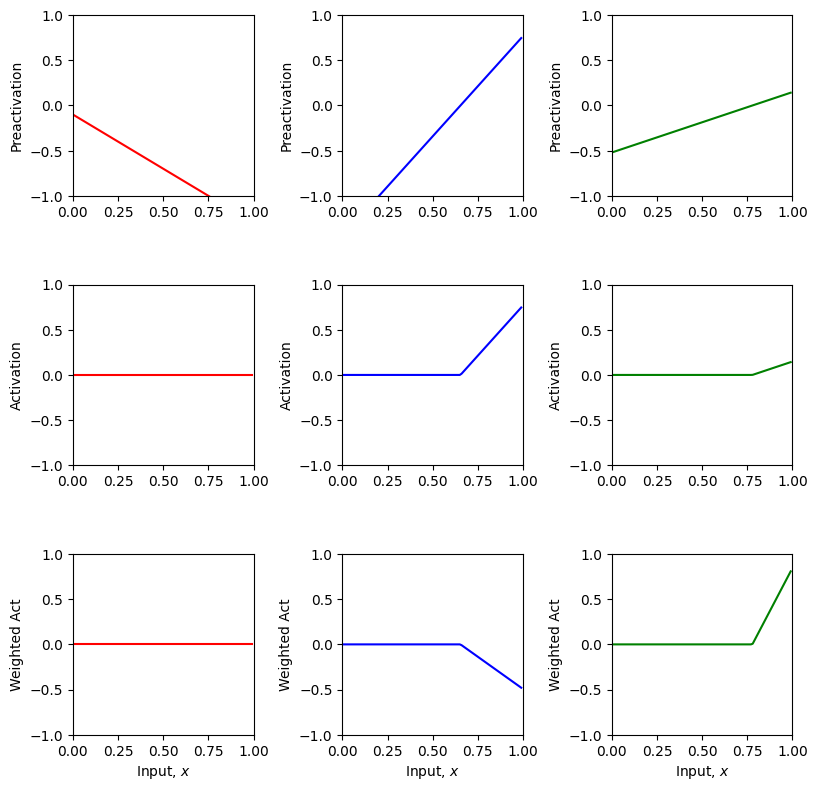

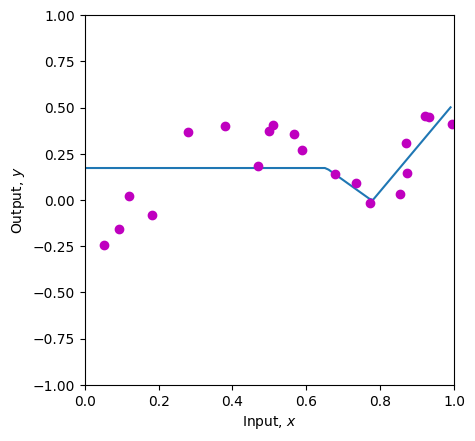

Tuned Loss = 0.669
Best params: {'theta_10': -0.1, 'theta_11': -1.2, 'theta_20': -1.4516, 'theta_21': 2.2203, 'theta_30': -0.5203, 'theta_31': 0.6688, 'phi_0': 0.1727, 'phi_1': 1.0, 'phi_2': -0.6426, 'phi_3': 5.7012}


In [ ]:
# Now lets define some parameters, run the neural network, and compute the loss
theta_10 =  0.3 ; theta_11 = -1.0
theta_20 = -1.0  ; theta_21 = 2.0
theta_30 = -0.5  ; theta_31 = 0.65
phi_0 = -0.3; phi_1 = 2.0; phi_2 = -1.0; phi_3 = 7.0

# Define a range of input values
x = np.arange(0,1,0.01)

x_train = np.array([0.09291784,0.46809093,0.93089486,0.67612654,0.73441752,0.86847339,\
                   0.49873225,0.51083168,0.18343972,0.99380898,0.27840809,0.38028817,\
                   0.12055708,0.56715537,0.92005746,0.77072270,0.85278176,0.05315950,\
                   0.87168699,0.58858043])
y_train = np.array([-0.15934537,0.18195445,0.451270150,0.13921448,0.09366691,0.30567674,\
                    0.372291170,0.40716968,-0.08131792,0.41187806,0.36943738,0.3994327,\
                    0.019062570,0.35820410,0.452564960,-0.0183121,0.02957665,-0.24354444, \
                    0.148038840,0.26824970])

# We run the neural network for each of these input values
y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3 = \
    shallow_1_1_3(x, ReLU, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31)
# And then plot it
plot_neural(x, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=True, x_data = x_train, y_data = y_train)

# Run the neural network on the training data
y_predict, *_ = shallow_1_1_3(x_train, ReLU, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31)

# Compute the least squares loss and print it out
loss = least_squares_loss(y_train,y_predict)
print('Your Loss = %3.3f, True value = 9.385'%(loss))

# TODO.  Manipulate the parameters (by hand!) to make the function
# fit the data better and try to reduce the loss to as small a number
# as possible.  The best that I could do was 0.181
# Tip... start by manipulating phi_0.
# It's not that easy, so don't spend too much time on this!

# ----- (completed) coordinate-descent parameter tuning to reduce loss -----
# The code below follows the TODO's spirit: first nudges phi_0, then other parameters.

def _eval_on(train_x, train_y, p):
    y_pred, *_ = shallow_1_1_3(train_x, ReLU,
                               p['phi_0'], p['phi_1'], p['phi_2'], p['phi_3'],
                               p['theta_10'], p['theta_11'], p['theta_20'], p['theta_21'], p['theta_30'], p['theta_31'])
    return least_squares_loss(train_y, y_pred)

params = {
    'theta_10': theta_10, 'theta_11': theta_11,
    'theta_20': theta_20, 'theta_21': theta_21,
    'theta_30': theta_30, 'theta_31': theta_31,
    'phi_0': phi_0, 'phi_1': phi_1, 'phi_2': phi_2, 'phi_3': phi_3,
}

# Start with phi_0 as suggested, then sweep others
order = ['phi_0','phi_1','phi_2','phi_3','theta_10','theta_11','theta_20','theta_21','theta_30','theta_31']
steps = {'phi_0':0.5,'phi_1':0.5,'phi_2':0.5,'phi_3':0.5,'theta_10':0.2,'theta_11':0.2,'theta_20':0.2,'theta_21':0.2,'theta_30':0.2,'theta_31':0.2}

best = _eval_on(x_train, y_train, params)
min_step = 1e-3
for _ in range(250):
    improved = False
    for k in order:
        for delta in (steps[k], -steps[k]):
            trial = params.copy()
            trial[k] = trial[k] + delta
            val = _eval_on(x_train, y_train, trial)
            if val < best - 1e-8:
                params, best, improved = trial, val, True
    if not improved:
        # shrink steps and stop when tiny
        for k in steps:
            steps[k] *= 0.5
        if all(steps[k] < min_step for k in steps):
            break

# Final plot with tuned parameters
y_tuned, pre1_t, pre2_t, pre3_t, act1_t, act2_t, act3_t, w1_t, w2_t, w3_t = \
    shallow_1_1_3(x, ReLU,
                  params['phi_0'], params['phi_1'], params['phi_2'], params['phi_3'],
                  params['theta_10'], params['theta_11'], params['theta_20'], params['theta_21'], params['theta_30'], params['theta_31'])
plot_neural(x, y_tuned, pre1_t, pre2_t, pre3_t, act1_t, act2_t, act3_t, w1_t, w2_t, w3_t,
            plot_all=True, x_data=x_train, y_data=y_train)

# Report tuned loss and parameters
print(f"Tuned Loss = {best:.3f}")
print('Best params:', {k: round(v, 4) for k, v in params.items()})
